In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import math
import geopandas as gpd
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.lines as mlines
from itertools import combinations

In [2]:
# Global settings
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Arial',
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize':14
})

In [3]:
# Load data 
data = pd.read_csv('openet_wheatfallow_data_2019_2024v2.csv')

In [4]:
data = data[data['HR']!='SV']
data['pr_et'] = data['gridmet_pr'] - data['ensemble_et']

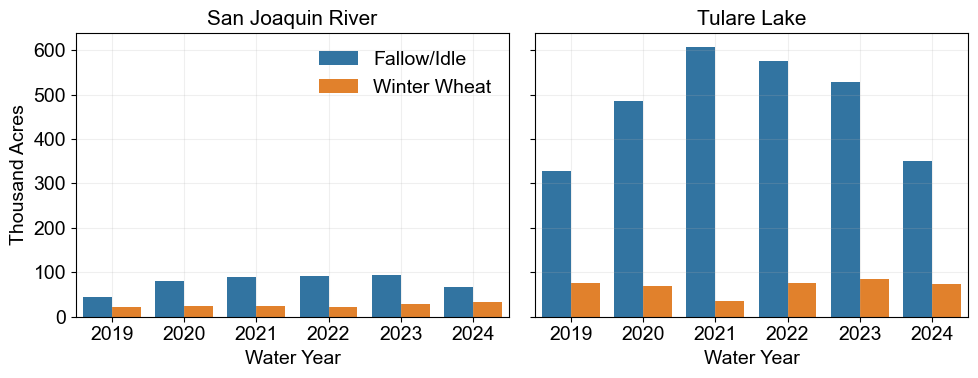

In [5]:
# Summarize total are per year, crop, and region
plot_acres = data[data['month']==1][['field_id', 'acres','water_year','HR','crop_name']].drop_duplicates()

summary_area = (
    plot_acres.groupby(['HR', 'water_year', 'crop_name'])['acres'].sum().reset_index()
)
regions = ['SJR', 'TL']
region_names = ['San Joaquin River', 'Tulare Lake']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, (reg, reg_name) in enumerate(zip(regions, region_names)):
    sub = summary_area[summary_area['HR'] == reg]
    sns.barplot(
        data=sub,
        x='water_year',
        y=sub['acres']/1000,
        hue='crop_name',
        ax=axes[i]
    )
    axes[i].set_title(reg_name)
    axes[i].set_xlabel('Water Year')
    axes[i].set_ylabel('Thousand Acres' if i == 0 else '')
    axes[i].legend(frameon=False, title='', loc='best')
    axes[i].grid(True, alpha=0.2)

    if i == 0:
        axes[i].legend(frameon=False, title='', loc='best')
    else:
        axes[i].get_legend().remove()



plt.tight_layout()
plt.show()

#### Acreage and Number of Fields by GSA and County

In [6]:
# Table of total acres by gsa, crop, and year
# Drop duplicate rows based on gsa, crop_name, water_year, and acres
count_table = data.drop_duplicates(subset=['gsa','field_id', 'crop_name', 'water_year', 'acres'])
count_table = count_table.groupby(['gsa', 'crop_name', 'water_year'])['acres'].sum().reset_index(name='total_acres')
count_table_pivot = count_table.pivot_table(index=['gsa', 'water_year'], columns='crop_name', values='total_acres', fill_value=0).reset_index()
count_table_pivot

crop_name,gsa,water_year,Fallow/Idle,Winter Wheat
0,CHOWCHILLA,2019,4957.356263,2021.637665
1,CHOWCHILLA,2020,6622.651221,2494.001112
2,CHOWCHILLA,2021,3836.628833,2779.395032
3,CHOWCHILLA,2022,5212.230244,3447.010966
4,CHOWCHILLA,2023,4618.130519,1679.424422
...,...,...,...,...
73,WHITE WOLF,2020,5068.004940,251.036441
74,WHITE WOLF,2021,6041.235395,0.000000
75,WHITE WOLF,2022,5535.493005,211.012844
76,WHITE WOLF,2023,6079.717057,158.574692


In [7]:
# Table of total acres by county, crop, and year
count_table = data.drop_duplicates(subset=['county', 'field_id','crop_name', 'water_year', 'acres'])
count_table = count_table.groupby(['county', 'crop_name', 'water_year'])['acres'].sum().reset_index(name='total_acres')
count_table_pivot = count_table.pivot_table(index=['county', 'water_year'], columns='crop_name', values='total_acres', fill_value=0).reset_index()
count_table_pivot

crop_name,county,water_year,Fallow/Idle,Winter Wheat
0,Fresno,2019,119074.127127,29369.533809
1,Fresno,2020,194502.787527,20128.481406
2,Fresno,2021,220821.753278,9105.371990
3,Fresno,2022,244645.304475,12888.445756
4,Fresno,2023,175908.872650,28701.285287
5,Fresno,2024,140819.745198,38953.330732
6,Kern,2019,101406.371674,15829.131164
7,Kern,2020,143886.819871,12601.514843
8,Kern,2021,166782.370712,6424.962279
9,Kern,2022,150912.756336,15263.366969


## Filtering 

In [8]:
# Remove water year 2019 and 2025
data = data[~data['water_year'].isin([2019,2025])]

# Keep combination of field_id - water years with complete months 
complete_pairs = (
    data.groupby(['field_id', 'water_year'])['month']
    .nunique()
    .reset_index()
    .query('month == 12')[['field_id', 'water_year']]
)

data = data.merge(complete_pairs, on=['field_id', 'water_year'], how='inner')


In [9]:
## First lets remove potentially missclasified fallow fields or those that are fallow but may have some vegetation (abandoned orchards, weeds, etc) and keep fields more than 5 acres for QA

# Filter 1: Remove all field_id that are 5 or less acres
data = data[data['acres'] > 5]

# Filter 2: Find field_id, water_year pairs where ALL NDVI values are > 0.1
positive_ndvi_pairs = (
    data.groupby(['field_id', 'water_year'])['landsat_ndvi']
    .apply(lambda x: (x > 0).all())
)
# Keep only those pairs where the result is True
positive_ndvi_pairs = positive_ndvi_pairs[positive_ndvi_pairs].index

# Filter the data to keep only those field_id, water_year pairs
data = data[data.set_index(['field_id', 'water_year']).index.isin(positive_ndvi_pairs)]

# Filter 3: Remove fallow/idle fields where any month has NDVI >= 0.5 in march-september months likely misclassified or with presence of vegetation/weeds 
# to keep fields that are close to barren soil
fallow_ids_with_high_ndvi = (
    data[(data['crop_name'] == 'Fallow/Idle') & (data['month'].isin([3,4,5,6,7,8,9]))]
    .groupby(['field_id','water_year'])['landsat_ndvi']
    .max()
    .loc[lambda x: x >= 0.5]
    .index
)

# Remove those field_ids from the data
data = data[~data.set_index(['field_id', 'water_year']).index.isin(fallow_ids_with_high_ndvi)]

# Filter 3: Remove wheat fields where NDVI is greater than 0.6 in months after May (likely to be double cropped - like wheat to corn)
# Identify field_ids for Winter Wheat where any month after May has NDVI > 0.6
wheat_ids_with_high_ndvi_post_june = (
    data[(data['crop_name'] == 'Winter Wheat') & (data['month'] > 5)]
    .groupby(['field_id','water_year'])['landsat_ndvi']
    .max()
    .loc[lambda x: x > 0.6]
    .index
)

# Remove those field_ids from the data
data = data[~data.set_index(['field_id', 'water_year']).index.isin(wheat_ids_with_high_ndvi_post_june)]

# Filter 4: Remove wheat fields where NDVI is lower than 0.4 in March - April (likely misclassified)
# Identify field_ids for Winter Wheat where March-May has NDVI < 0.4
wheat_ids_with_low_ndvi_peakseason = data[(data['crop_name'] == 'Winter Wheat')  & (data['month'].isin([3,4,5]))].groupby(
    ['field_id','water_year'])['landsat_ndvi'].max().loc[lambda x: x < 0.4].index


# Remove those field_ids from the data
data = data[~data.set_index(['field_id', 'water_year']).index.isin(wheat_ids_with_low_ndvi_peakseason)]

In [10]:
# Count of fields after filtering

count_table = data.drop_duplicates(subset=['HR', 'field_id','crop_name', 'water_year', 'acres'])
# count unique field_id per county, crop_name, water_year
field_counts = count_table.groupby(['HR', 'crop_name', 'water_year'])['field_id'].nunique().reset_index(name='num_fields')
field_counts_pivot = field_counts.pivot_table(index=['HR', 'water_year'], columns='crop_name', values='num_fields', fill_value=0).reset_index()
field_counts_pivot

crop_name,HR,water_year,Fallow/Idle,Winter Wheat
0,SJR,2020,1181.0,543.0
1,SJR,2021,1471.0,540.0
2,SJR,2022,1938.0,428.0
3,SJR,2023,1055.0,658.0
4,SJR,2024,330.0,534.0
5,TL,2020,6400.0,890.0
6,TL,2021,9617.0,491.0
7,TL,2022,7863.0,901.0
8,TL,2023,3668.0,1113.0
9,TL,2024,1670.0,749.0


## Wide Data

In [11]:
# Make data horizontal: pivot so each month is a column 
data_wide = data.pivot_table(
    index=['field_id', 'crop_name','water_year','gsa',
           'HR','county'],
    columns='month',
    values='pr_et' # This is ET - Pr (in mm)
).reset_index()

data_wide.loc[:,'pr_et_mm_novapr'] = data_wide[[11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide.loc[:,'pr_et_mm_octapr'] = data_wide[[10,11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide.loc[:,'pr_et_mm_octsep'] = data_wide[[10,11,12,1,2,3,4,5,6,7,8,9]].sum(axis=1)

data_wide = data_wide.drop(columns=[1,2,3,4,5,6,7,8,9,10,11,12])

# Make data horizontal: pivot so each month is a column 
data_wide_2 = data.pivot_table(
    index=['field_id', 'crop_name','water_year'],
    columns='month',
    values='landsat_ndvi'
).reset_index()

data_wide_2.loc[:,'max_ndvi'] = data_wide_2[[1, 2, 3, 4, 10, 11, 12]].max(axis=1)

data_wide = data_wide.merge(data_wide_2[['field_id','water_year','max_ndvi']], on=['field_id','water_year'], how='left')

# Make data horizontal: pivot so each month is a column 
data_wide_2 = data.pivot_table(
    index=['field_id','water_year'],
    columns='month',
    values='ensemble_et'
).reset_index()

data_wide_2.loc[:,'et_ensemble_novapr'] = data_wide_2[[11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide_2.loc[:,'et_ensemble_octapr'] = data_wide_2[[10, 11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide_2.loc[:,'et_ensemble_octsep'] = data_wide_2[[10,11,12,1,2,3,4,5,6,7,8,9]].sum(axis=1)
data_wide_2 = data_wide_2.drop(columns=[1,2,3,4,5,6,7,8,9,10,11,12])

data_wide = data_wide.merge(data_wide_2, on=['field_id','water_year'], how='left')

data_wide_2 = data.pivot_table(
    index=['field_id','water_year'],
    columns='month',
    values='gridmet_pr'
).reset_index()

data_wide_2.loc[:,'pr_novapr'] = data_wide_2[[11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide_2.loc[:,'pr_octapr'] = data_wide_2[[10, 11, 12, 1, 2, 3, 4]].sum(axis=1)
data_wide_2.loc[:,'pr_octsep'] = data_wide_2[[10,11,12,1,2,3,4,5,6,7,8,9]].sum(axis=1)
data_wide_2 = data_wide_2.drop(columns=[1,2,3,4,5,6,7,8,9,10,11,12])

data_wide = data_wide.merge(data_wide_2, on=['field_id','water_year'], how='left')

data_wide_2 = data.pivot_table(
    index=['field_id','water_year'],
    columns='month',
    values='gridmet_eto'
).reset_index()

data_wide_2.loc[:,'eto_novapr'] = data_wide_2[[11,12,1,2,3,4]].sum(axis=1)
data_wide_2.loc[:,'eto_octapr'] = data_wide_2[[10, 11, 12,1,2,3,4]].sum(axis=1)
data_wide_2.loc[:,'eto_octsep'] = data_wide_2[[10,11,12,1,2,3,4,5,6,7,8,9]].sum(axis=1)
data_wide_2 = data_wide_2.drop(columns=[1,2,3,4,5,6,7,8,9,10,11,12])

data_wide = data_wide.merge(data_wide_2, on=['field_id','water_year'], how='left')

data_wide

month,field_id,crop_name,water_year,gsa,HR,county,pr_et_mm_novapr,pr_et_mm_octapr,pr_et_mm_octsep,max_ndvi,et_ensemble_novapr,et_ensemble_octapr,et_ensemble_octsep,pr_novapr,pr_octapr,pr_octsep,eto_novapr,eto_octapr,eto_octsep
0,640511,Fallow/Idle,2024,TULE,TL,Tulare,-160.610,-257.763,-609.192,0.379,366.710,465.194,822.187,206.100,207.431,212.995,405.870,504.237,1525.400
1,640517,Winter Wheat,2022,TULE,TL,Tulare,-243.555,-294.720,-567.933,0.837,368.641,438.052,717.470,125.086,143.332,149.537,420.199,515.728,1552.452
2,640517,Winter Wheat,2023,TULE,TL,Tulare,-32.721,-73.566,-265.154,0.877,338.495,379.340,597.546,305.774,305.774,332.392,372.515,483.461,1412.921
3,640525,Fallow/Idle,2021,TULE,TL,Tulare,-75.170,-98.911,-285.173,0.270,166.971,190.712,376.974,91.801,91.801,91.801,445.546,545.948,1591.318
4,640525,Fallow/Idle,2022,TULE,TL,Tulare,-111.726,-120.837,-318.424,0.424,234.935,262.153,465.632,123.209,141.316,147.208,418.197,513.265,1543.577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42035,6414075,Winter Wheat,2021,TULARE LAKE,TL,Kings,-268.057,-292.439,-521.044,0.852,373.643,398.025,626.630,105.586,105.586,105.586,460.971,565.301,1663.989
42036,6414158,Fallow/Idle,2021,MENDOTA,SJR,Stanislaus,19.882,1.754,-178.828,0.235,143.434,161.562,342.291,163.316,163.316,163.463,419.306,519.214,1467.646
42037,6418021,Winter Wheat,2020,TULE,TL,Tulare,-149.972,-164.430,-366.061,0.840,335.076,349.534,556.060,185.104,185.104,189.999,398.478,502.597,1460.045
42038,6418021,Winter Wheat,2021,TULE,TL,Tulare,-229.963,-243.936,-493.637,0.801,327.355,341.328,591.965,97.392,97.392,98.328,440.387,539.818,1578.360


## Thresholding

In [12]:
# Thresholds based on NDVI and Pr-ET based on spatial criteria
spatial_criteria = 'HR' # Could be gsa, HR or county

# Calculate max NDVI per field 
max_ndvi_per_field = (
    data
    .groupby(['field_id',spatial_criteria, 'water_year', 'crop_name'])['landsat_ndvi']
    .max()
    .reset_index()
)

# Calculate 25th and 75th percentiles of those max NDVI values by group
ndvi_percentiles = (
    max_ndvi_per_field
    .groupby([spatial_criteria, 'water_year', 'crop_name'])['landsat_ndvi']
    .quantile([0.25, 0.75])
    .unstack(level=-1)
    .reset_index()
    .rename(columns={0.25: 'ndvi_25th', 0.75: 'ndvi_75th'})
)

# Merge percentiles back to main data
max_ndvi_per_field = max_ndvi_per_field.merge(ndvi_percentiles, on=[spatial_criteria, 'water_year', 'crop_name'], how='left')

# # Assign ndvi_cat based on the max landsat_ndvi per field 
max_ndvi_per_field['ndvi_cat'] = np.select(
        [
            max_ndvi_per_field['landsat_ndvi'] <= max_ndvi_per_field['ndvi_25th'], # NDVI 25th
             (max_ndvi_per_field['landsat_ndvi'] > max_ndvi_per_field['ndvi_25th']) & (max_ndvi_per_field['landsat_ndvi'] < max_ndvi_per_field['ndvi_75th']), # NDVI IQR
            max_ndvi_per_field['landsat_ndvi'] >= max_ndvi_per_field['ndvi_75th'] # NDVI 75th
        ],
        ['NDVI 25th', 'NDVI IQR', 'NDVI 75th'],
        default= 'NA'
    )

data = data.merge(max_ndvi_per_field[['field_id','water_year','ndvi_cat']], on=['field_id','water_year'], how='left')

In [13]:
# Do the same for pr_et using et_ensemble_novmay
# Calculate 25th and 75th percentiles for each region and year for the month of interest
# Change the irrigation assumption where needed

pr_et_fallow = pr_et_percentiles = (
    data_wide[data_wide['crop_name'] == 'Fallow/Idle'] # We assume that values bellow 127 mm (5 inches)/152 mm (6 inches) are parcels likely dry irrigated 
    .groupby([spatial_criteria, 'water_year'])['et_ensemble_novapr']
    .quantile(0.95)
    .reset_index()
    .rename(columns={'et_ensemble_novapr': 'fallow_irr_threshold'})
)

# Merge the 95th percentile threshold to data_wide
data_wide = data_wide.merge(pr_et_fallow, on=[spatial_criteria, 'water_year'], how='left')

# Use the threshold for filtering
pr_et_percentiles = (
    data_wide[data_wide['et_ensemble_novapr'] > data_wide['fallow_irr_threshold']]
    .groupby([spatial_criteria, 'water_year', 'crop_name'])['et_ensemble_novapr']
    .quantile([0.25, 0.75])
    .unstack(level=-1)
    .reset_index()
    .rename(columns={0.25: 'et_25th', 0.75: 'et_75th'})
)

# Merge percentiles back to main data
data_wide = data_wide.merge(pr_et_percentiles, on=[spatial_criteria, 'water_year', 'crop_name'], how='left')

# Assign et_cat based on percentiles
data_wide['et_cat'] = np.select(
    [
        data_wide['et_ensemble_novapr'] <= data_wide['et_25th'], #0
        data_wide['et_ensemble_novapr'] >= data_wide['et_75th'], #2
        (data_wide['et_ensemble_novapr'] > data_wide['et_25th']) & (data_wide['et_ensemble_novapr'] < data_wide['et_75th']),
    ],
    ['ET 25th', 'ET 75th', 'ET IQR'],
    default= 'NA'
    )

data_wide.loc[data_wide['et_ensemble_novapr'] < data_wide['fallow_irr_threshold'], 'et_cat'] = 'Non-Irrigated' # 6 inches 152 mm or 5 inches 127 mm

# Group by field_id and water_year if a month was classified as 0 or 2, assign that classification to the entire field-year
data_wide['irr_cat'] = np.where(
    data_wide['et_cat'] == 'ET 25th',
    'Likely Irrigated',
    np.where(
        data_wide['et_cat'] == 'ET IQR',
        'Irrigated',
        np.where(
            data_wide['et_cat'] == 'ET 75th',
            'Irrigated',
            np.where(
                data_wide['et_cat'] == 'Non-Irrigated',
                'Non-Irrigated',
                'NA'  # default value if none of the above
            )
        )
    )
)

data_wide['irr_cat'].loc[data_wide['crop_name'] == 'Fallow/Idle'] = 'Fallow/Idle' # All fallow fields are non-irrigated

# merge et_cat to main data
data = data.merge(data_wide[['et_cat','field_id','water_year','irr_cat']].drop_duplicates(),
                  on=['field_id','water_year'],how='left')


# merge categories to data in wide format
data_wide = data_wide.merge(
    data[['field_id', 'water_year', 'ndvi_cat']].drop_duplicates(),
    on=['field_id', 'water_year'],
    how='left'
)


/var/folders/5j/xzmrwmg542db1gdvqrh75pm80000gn/T/ipykernel_98957/1674915128.py:61: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data_wide['irr_cat'].loc[data_wide['crop_name'] == 'Fallow/Idle'] = 'Fallow/Idle' # All fallow fields are non-ir

In [14]:
# Table of total acres by county, crop, and year
count_table = data.drop_duplicates(subset=['county', 'field_id','crop_name', 'water_year', 'acres'])
count_table = count_table.groupby(['county', 'crop_name', 'water_year'])['acres'].sum().reset_index(name='total_acres')
count_table_pivot = count_table.pivot_table(index=['county', 'water_year'], columns='crop_name', values='total_acres', fill_value=0).reset_index()
count_table_pivot

crop_name,county,water_year,Fallow/Idle,Winter Wheat
0,Fresno,2020,178343.860147,16616.546072
1,Fresno,2021,198133.241832,8990.527470
2,Fresno,2022,226629.630124,9782.758455
3,Fresno,2023,71245.770744,26993.090430
4,Fresno,2024,57246.251951,36746.940071
5,Kern,2020,122509.509332,9254.045184
6,Kern,2021,161722.179232,5763.956404
7,Kern,2022,137718.814669,11898.127989
8,Kern,2023,52263.616846,13890.876609
9,Kern,2024,14971.246851,6585.637363


In [15]:
count_table = data.drop_duplicates(subset=['county', 'field_id','crop_name', 'water_year', 'acres'])
# count unique field_id per county, crop_name, water_year
field_counts = count_table.groupby(['county', 'crop_name', 'water_year'])['field_id'].nunique().reset_index(name='num_fields')
field_counts_pivot = field_counts.pivot_table(index=['county', 'water_year'], columns='crop_name', values='num_fields', fill_value=0).reset_index()
field_counts_pivot

crop_name,county,water_year,Fallow/Idle,Winter Wheat
0,Fresno,2020,2541.0,239.0
1,Fresno,2021,2932.0,138.0
2,Fresno,2022,3487.0,152.0
3,Fresno,2023,1541.0,336.0
4,Fresno,2024,905.0,366.0
5,Kern,2020,2048.0,164.0
6,Kern,2021,2896.0,98.0
7,Kern,2022,2278.0,202.0
8,Kern,2023,1097.0,249.0
9,Kern,2024,332.0,124.0


#### PPIC Categories based on NDVI

In [16]:
data['ppic_cat'] = np.select(
    [
        data['ndvi_cat'] == 'NDVI 75th',
        data['ndvi_cat'] == 'NDVI 25th'
    ],
    [
        'Fully Irrigated',
        'Stressed'
    ],
    default='NDVI IQR'
)

data_wide['ppic_cat'] = np.select(
    [
        data_wide['ndvi_cat'] == 'NDVI 75th',
        data_wide['ndvi_cat'] == 'NDVI 25th'
    ],
    [
        'Fully Irrigated',
        'Stressed'
        
    ],
    default='NDVI IQR'
)

data_wide.loc[data_wide['crop_name'] == 'Fallow/Idle','ppic_cat'] = 'Fallow'
data.loc[data['crop_name'] == 'Fallow/Idle','ppic_cat'] = 'Fallow'

In [17]:
# Color palettes 

et_categories = ['Non-Irrigated','ET 25th', 'ET IQR', 'ET 75th']
et_palette = dict(zip(et_categories, sns.color_palette("Set2", len(et_categories))))

categories = ['NDVI 25th', 'NDVI IQR', 'NDVI 75th']
ndvi_palette = dict(zip(categories, sns.color_palette("Accent", len(categories))))

ppic_categories = ['Fully Irrigated','Stressed','Fallow']
ppic_palette = dict(zip(ppic_categories, sns.color_palette("Accent", len(ppic_categories))))

crop_names = data['crop_name'].unique()
crop_palette = dict(zip(crop_names, sns.color_palette("Set2", len(crop_names))))


### Plots

In [18]:
# For plots
ordered_months = ['10', '11', '12', '1', '2', '3', '4', '5', '6', '7', '8', '9']
hr_regions = ['SJR', 'TL']
region_names = ['San Joaquin River', 'Tulare Lake']

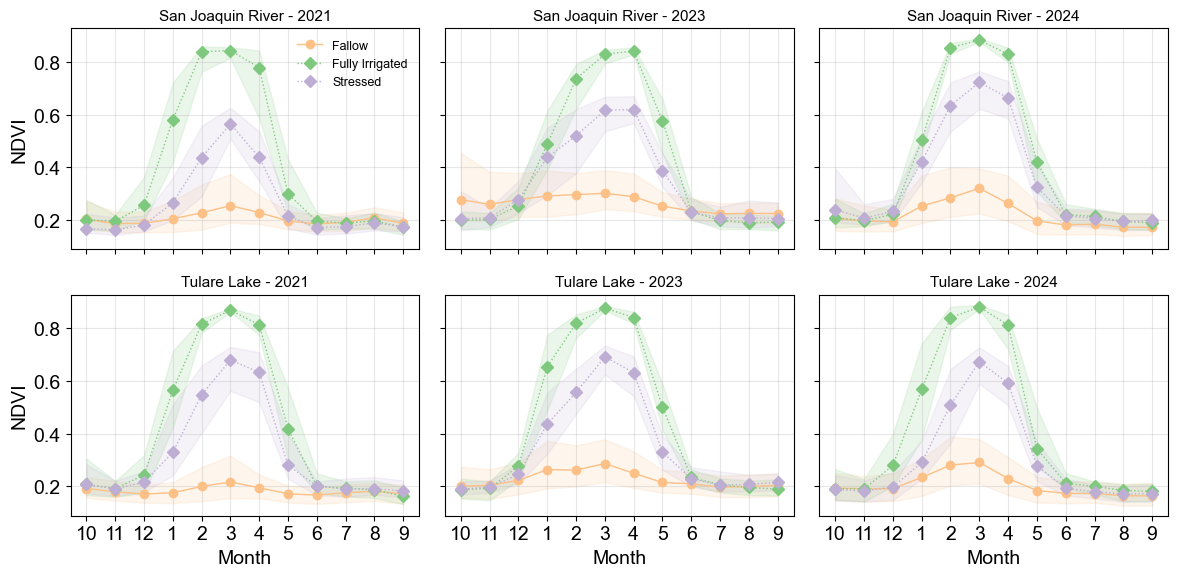

In [19]:
years = [2021, 2023, 2024]
line_styles = {'Fallow/Idle': '-', 'Winter Wheat': ':'}

fig, axes = plt.subplots(2, len(years), figsize=(12, 6), sharey=True, sharex=True)

for col, year in enumerate(years):
    for row, (hr, region_name) in enumerate(zip(hr_regions, region_names)):
        subset = data[(data['HR'] == hr) & (data['water_year'] == year)].copy()
        subset["month"] = subset["month"].astype(str)
        ax = axes[row, col]

        # --- Fallow/Idle: ---
        fallow_subset = subset[subset['crop_name'] == 'Fallow/Idle']

        ndvi_fallow_pivot = fallow_subset.pivot_table(
            index='field_id', columns='month', values='landsat_ndvi', aggfunc='median'
        ).reindex(columns=ordered_months, fill_value=np.nan)

        ndvi_fallow_median = ndvi_fallow_pivot.median(axis=0)
        ndvi_fallow_p25 = ndvi_fallow_pivot.quantile(0.25, axis=0)
        ndvi_fallow_p75 = ndvi_fallow_pivot.quantile(0.75, axis=0)

        fallow_color = ppic_palette['Fallow']
        ax.plot(ordered_months, ndvi_fallow_median, label='Fallow',
                linestyle=line_styles['Fallow/Idle'], marker='o',
                color=fallow_color, linewidth=1)
        ax.fill_between(ordered_months, ndvi_fallow_p25, ndvi_fallow_p75,
                        color=fallow_color, alpha=0.15)

        # --- Winter Wheat: plot by ppic_category (exclude Fallow) ---
        ww_subset = subset[subset['crop_name'] == 'Winter Wheat']
        for ppic_cat in ['Fully Irrigated', 'Stressed']:
            ppic_ww = ww_subset[ww_subset['ppic_cat'] == ppic_cat]
            
            ndvi_ww_pivot = ppic_ww.pivot_table(
                index='field_id', columns='month', values='landsat_ndvi', aggfunc='median'
            ).reindex(columns=ordered_months, fill_value=np.nan)

            ndvi_ww_median = ndvi_ww_pivot.median(axis=0)
            ndvi_ww_p25 = ndvi_ww_pivot.quantile(0.25, axis=0)
            ndvi_ww_p75 = ndvi_ww_pivot.quantile(0.75, axis=0)

            color = ppic_palette[ppic_cat]
            ax.plot(ordered_months, ndvi_ww_median, label=f'{ppic_cat}',
                    linestyle=line_styles['Winter Wheat'], marker='D',
                    color=color, linewidth=1)
            ax.fill_between(ordered_months, ndvi_ww_p25, ndvi_ww_p75,
                            color=color, alpha=0.15)

        ax.set_title(f'{region_name} - {year}', fontsize=11)
        if row == 1:
            ax.set_xlabel('Month')
        if col == 0:
            ax.set_ylabel('NDVI')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(loc='best', frameon=False, fontsize=9)

# fig.supxlabel('Month', fontsize=12)
plt.tight_layout()
plt.show()

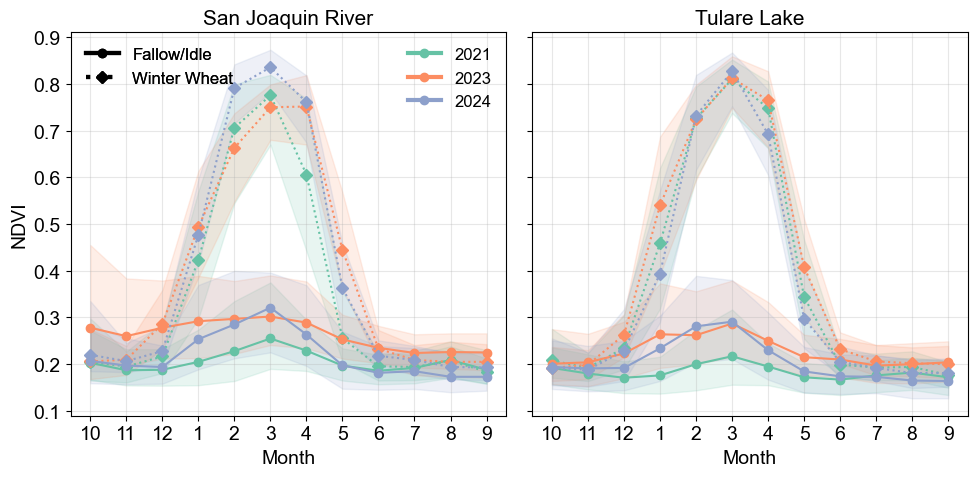

In [20]:
years = [2021, 2023, 2024]

year_palette = dict(zip(years, sns.color_palette("Set2", len(years))))
line_styles = {'ET_Fallow': '-', 'ET_WW': ':'}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for i, (hr, region_name) in enumerate(zip(hr_regions, region_names)):
    subset = data[(data['HR'] == hr) & (data['water_year'].isin(years))]
    ax = axes[i]
    for year in years:
        df = subset[subset['water_year'] == year].copy()
        df["month"] = df["month"].astype(str)
        
        # Fallow/Idle fields NDVI
        ndvi_fallow_pivot = df[df['crop_name'] == 'Fallow/Idle'].pivot_table(index='field_id', columns='month', values='landsat_ndvi', aggfunc='median').reindex(columns=ordered_months, fill_value=np.nan)
        # Winter Wheat fields NDVI
        ndvi_ww_pivot = df[df['crop_name'] == 'Winter Wheat'].pivot_table(index='field_id', columns='month', values='landsat_ndvi', aggfunc='median').reindex(columns=ordered_months, fill_value=np.nan)

        # Calculate percentiles (not cumulative)
        ndvi_fallow_median = ndvi_fallow_pivot.median(axis=0)
        ndvi_fallow_p25 = ndvi_fallow_pivot.quantile(0.25, axis=0)
        ndvi_fallow_p75 = ndvi_fallow_pivot.quantile(0.75, axis=0)
        ndvi_ww_median = ndvi_ww_pivot.median(axis=0)
        ndvi_ww_p25 = ndvi_ww_pivot.quantile(0.25, axis=0)
        ndvi_ww_p75 = ndvi_ww_pivot.quantile(0.75, axis=0)

        ax.plot(ordered_months, ndvi_fallow_median, label=f'{year} NDVI (Fallow)', linestyle=line_styles['ET_Fallow'], marker='o', color=year_palette[year])
        ax.fill_between(ordered_months, ndvi_fallow_p25, ndvi_fallow_p75, color=year_palette[year], alpha=0.15)
        ax.plot(ordered_months, ndvi_ww_median, label=f'{year} NDVI (WW)', linestyle=line_styles['ET_WW'], marker='D', color=year_palette[year])
        ax.fill_between(ordered_months, ndvi_ww_p25, ndvi_ww_p75, color=year_palette[year], alpha=0.15)
        # ax.axvline(x='5', color='gray', linestyle='--', alpha=0.7)  # vertical line at May (month 5)

    ax.set_xticks(ordered_months)
    ax.set_title(region_name)
    ax.set_xlabel('Month')
    if i == 0:
        ax.set_ylabel('NDVI')
    else:
        ax.set_ylabel('')
    ax.grid(True, alpha=0.3)

# Custom legends
year_handles = [mlines.Line2D([], [], color=year_palette[year], marker='o', linestyle='-', linewidth=3, label=str(year)) for year in years]
type_handles = [
    mlines.Line2D([], [], color='black', linestyle=line_styles['ET_Fallow'], marker='o', linewidth=3, label='Fallow/Idle'),
    mlines.Line2D([], [], color='black', linestyle=line_styles['ET_WW'], marker='D', linewidth=3, label='Winter Wheat'),
]

leg1 = axes[0].legend(handles=year_handles, title='', frameon=False, loc='upper right',fontsize=12)
axes[0].add_artist(leg1)
leg2 = axes[0].legend(handles=type_handles, title='', frameon=False, loc='upper left',fontsize=12)
axes[0].add_artist(leg2)


plt.tight_layout()
plt.show()

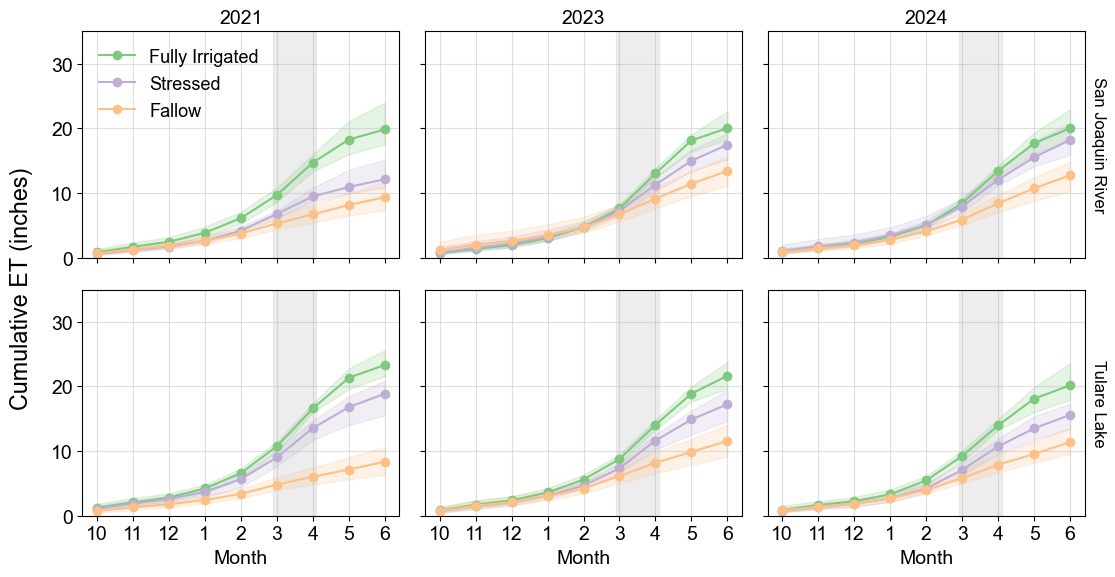

In [21]:
years = [2021, 2023, 2024]

# only show Oct–Jun (hide Jul–Sep)
plot_months = ['10', '11', '12', '1', '2', '3', '4', '5', '6']
x_vals = np.arange(len(plot_months))

n_regions = len(hr_regions)
n_years = len(years)

fig, axes = plt.subplots(n_regions, n_years, figsize=(12, 6), sharey=True, sharex=True)

for row, (hr, region_name) in enumerate(zip(hr_regions, region_names)):
    for col, year in enumerate(years):
        ax = axes[row, col]

        subset = data[
            (data['HR'] == hr) &
            (data['water_year'] == year)
        ].copy()
        subset["month"] = subset["month"].astype(str)

        # light gray band for March–April
        m_idx = plot_months.index('3')
        a_idx = plot_months.index('4')
        ax.axvspan(m_idx - 0.1, a_idx + 0.1, color='lightgray', alpha=0.4, zorder=0)

        for ppic_cat in ['Fully Irrigated', 'Stressed','Fallow']:
            df = subset[subset['ppic_cat'] == ppic_cat].copy()
            pivot = df.pivot_table(
                index='field_id', columns='month', values='ensemble_et', aggfunc='sum'
            ).reindex(columns=plot_months, fill_value=0)

            pivot = pivot / 25.4  # mm to inches
            cum = pivot.cumsum(axis=1)
            median = cum.median(axis=0)
            p25 = cum.quantile(0.25, axis=0)
            p75 = cum.quantile(0.75, axis=0)

            ax.plot(x_vals, median, label=ppic_cat, color=ppic_palette[ppic_cat], marker="o", linewidth=1.5)
            ax.fill_between(x_vals, p25, p75, color=ppic_palette[ppic_cat], alpha=0.2)

        # Year label at top row only
        ax.set_title(f'{year}' if row == 0 else '', fontsize=14)

        # Region label on right side
        if col == n_years - 1:
            ax.text(1.02, 0.5, region_name, va='center', ha='left',
                    fontsize=12, transform=ax.transAxes, rotation=-90)

        # Legend only on top-left subplot
        if row == 0 and col == 0:
            ax.legend(frameon=False, loc='upper left', fontsize=13)
        else:
            if ax.get_legend():
                ax.get_legend().remove()

        ax.set_xticks(x_vals)
        ax.set_xticklabels(plot_months)

        if row == n_regions - 1:
            ax.set_xlabel('Month')
        else:
            ax.set_xlabel('')

        ax.grid(True, alpha=0.4)
        ax.set_ylim(0, 35)

fig.supylabel('Cumulative ET (inches)')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

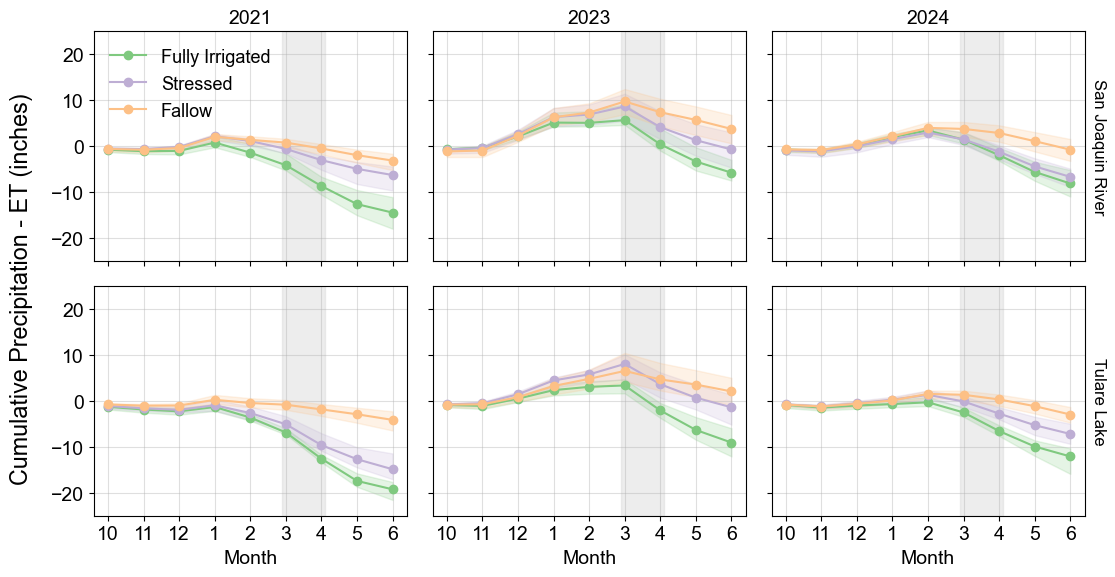

In [22]:
years = [2021, 2023, 2024]

# only show Oct–Jun (hide Jul–Sep)
plot_months = ['10', '11', '12', '1', '2', '3', '4', '5', '6']
x_vals = np.arange(len(plot_months))

n_regions = len(hr_regions)
n_years = len(years)

fig, axes = plt.subplots(n_regions, n_years, figsize=(12, 6), sharey=True, sharex=True)

for row, (hr, region_name) in enumerate(zip(hr_regions, region_names)):
    for col, year in enumerate(years):
        ax = axes[row, col]

        subset = data[
            (data['HR'] == hr) &
            (data['water_year'] == year)
        ].copy()
        subset["month"] = subset["month"].astype(str)

        # light gray band for March–April
        m_idx = plot_months.index('3')
        a_idx = plot_months.index('4')
        ax.axvspan(m_idx - 0.1, a_idx + 0.1, color='lightgray', alpha=0.4, zorder=0)

        for ppic_cat in ['Fully Irrigated', 'Stressed','Fallow']:
            df = subset[subset['ppic_cat'] == ppic_cat].copy()
            pivot = df.pivot_table(
                index='field_id', columns='month', values='pr_et', aggfunc='sum'
            ).reindex(columns=plot_months, fill_value=0)

            pivot = pivot / 25.4  # mm to inches
            cum = pivot.cumsum(axis=1)
            median = cum.median(axis=0)
            p25 = cum.quantile(0.25, axis=0)
            p75 = cum.quantile(0.75, axis=0)

            ax.plot(x_vals, median, label=ppic_cat, color=ppic_palette[ppic_cat], marker="o", linewidth=1.5)
            ax.fill_between(x_vals, p25, p75, color=ppic_palette[ppic_cat], alpha=0.2)

        
        # Year label at top row only
        ax.set_title(f'{year}' if row == 0 else '', fontsize=14)

        # Region label on right side
        if col == n_years - 1:
            ax.text(1.02, 0.5, region_name, va='center', ha='left',
                    fontsize=12, transform=ax.transAxes, rotation=-90)

        # Legend only on top-left subplot
        if row == 0 and col == 0:
            ax.legend(frameon=False, loc='upper left', fontsize=13)
        else:
            if ax.get_legend():
                ax.get_legend().remove()

        ax.set_xticks(x_vals)
        ax.set_xticklabels(plot_months)


        if row == n_regions - 1:
            ax.set_xlabel('Month')
        else:
            ax.set_xlabel('')

        ax.grid(True, alpha=0.4)
        ax.set_ylim(-25, 25)

fig.supylabel('Cumulative Precipitation - ET (inches)')
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

### Water Year Plots Showing Winter Wheat Groing Season (November-April)

In [23]:
variable = 'et_ensemble_novapr'

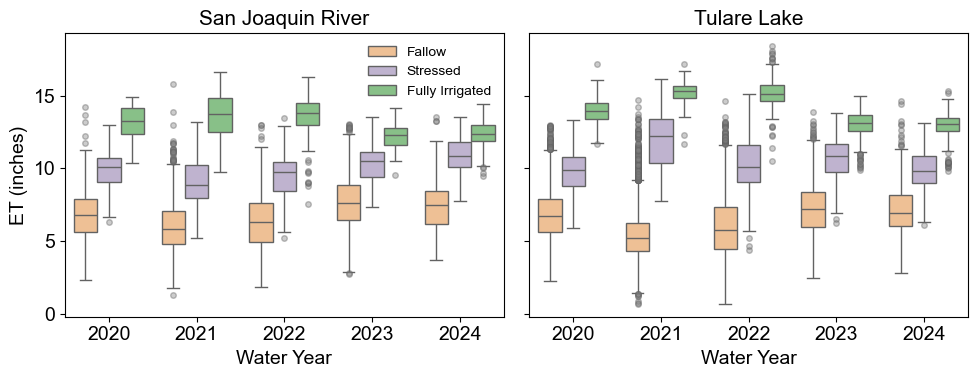

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, (reg, reg_name) in enumerate(zip(regions, region_names)):
    subset = data_wide[(data_wide['HR'] == reg) & (data_wide['ppic_cat'] != 'NDVI IQR')]
    sns.boxplot(
        data=subset,
        x='water_year',
        y=subset[variable]/25.4,  # Convert mm to inches
        hue='ppic_cat',
        palette=ppic_palette,
        ax=axes[i],
        showcaps=True,
        boxprops={'zorder': 2},
        whiskerprops={'zorder': 2},
        medianprops={'zorder': 3},
        hue_order = ["Fallow","Stressed","Fully Irrigated"],
        flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.4)
    )
    axes[i].set_title(f'{reg_name}')
    axes[i].set_xlabel('Water Year')
    if i == 0:
        axes[i].set_ylabel('ET (inches)')
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='x')
    if i == 0:
        axes[i].legend(frameon=False, title='', loc='upper right',  ncol=1, fontsize = 10)
    else:
        axes[i].get_legend().remove()


plt.tight_layout()
plt.show()

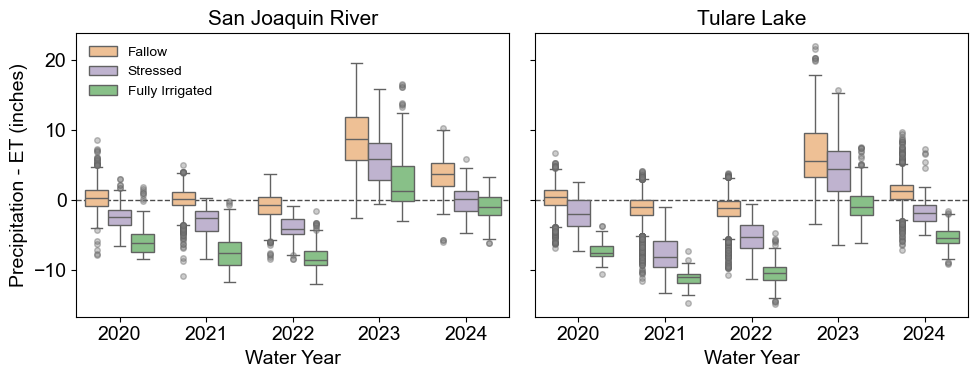

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, (reg, reg_name) in enumerate(zip(regions, region_names)):
    subset = data_wide[(data_wide['HR'] == reg) & (data_wide['ppic_cat'] != 'NDVI IQR')]
    sns.boxplot(
        data=subset,
        x='water_year',
        y=subset['pr_et_mm_novapr']/25.4,  # Convert mm to inches
        hue='ppic_cat',
        palette=ppic_palette,
        ax=axes[i],
        showcaps=True,
        hue_order = ["Fallow","Stressed","Fully Irrigated"],
        boxprops={'zorder': 2},
        whiskerprops={'zorder': 2},
        medianprops={'zorder': 3},
        flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.4)
    )
    axes[i].axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
    axes[i].set_title(f'{reg_name}')
    axes[i].set_xlabel('Water Year')
    if i == 0:
        axes[i].set_ylabel('Precipitation - ET (inches)')
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='x')
    if i == 0:
        axes[i].legend(frameon=False, title='', loc='best', fontsize=10)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

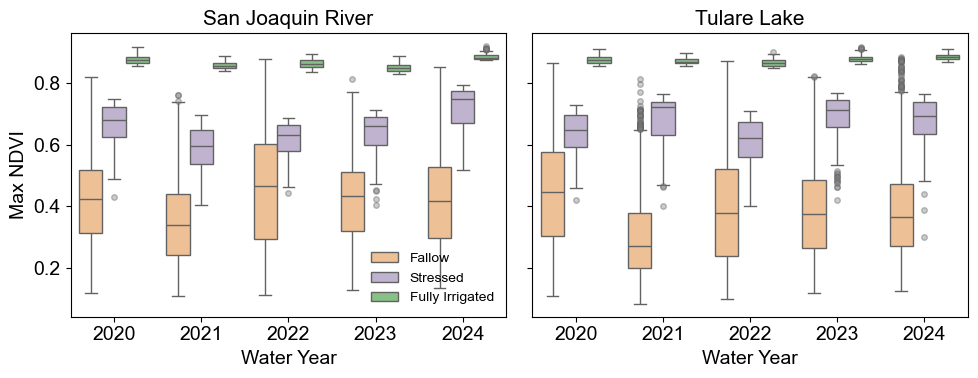

In [26]:
fig, axes = plt.subplots(1,2, figsize=(10, 4), sharey=True)

for i, (reg, reg_name) in enumerate(zip(regions, region_names)):
    subset = data_wide[(data_wide['HR'] == reg) & (data_wide['ppic_cat'] != 'NDVI IQR')]
    sns.boxplot(
        data=subset,
        x='water_year',
        y='max_ndvi',
        hue='ppic_cat',
        palette=ppic_palette,
        ax=axes[i],
        showcaps=True,
        boxprops={'zorder': 2},
        whiskerprops={'zorder': 2},
        medianprops={'zorder': 3},
        hue_order = ["Fallow","Stressed","Fully Irrigated"],
        flierprops=dict(marker='o', markersize=4, markerfacecolor='gray', alpha=0.4)
    )
    axes[i].set_title(f'{reg_name}')
    axes[i].set_xlabel('Water Year')
    if i == 0:
        axes[i].set_ylabel('Max NDVI')
    else:
        axes[i].set_ylabel('')
    axes[i].tick_params(axis='x')
    if i == 0:
        axes[i].legend(frameon=False, title='', loc='lower right',  ncol=1, fontsize = 10)
    else:
        axes[i].get_legend().remove()


plt.tight_layout()
plt.show()

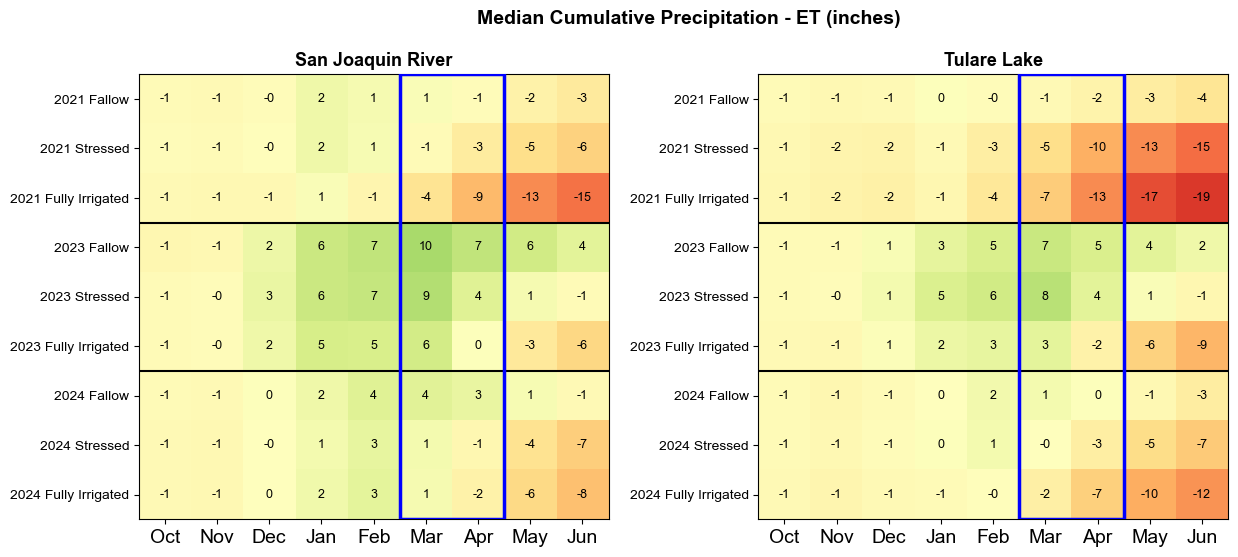

In [27]:
# Create a heatmap: Cumulative ET - Precipitation by region, water year, and irrigation category
# Side-by-side layout for two regions with box around March-April and horizontal lines for each year

import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

years = [2021, 2023, 2024]
plot_months = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
month_nums = ['10', '11', '12', '1', '2', '3', '4', '5', '6']

# Prepare data for heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for region_idx, (hr, region_name) in enumerate(zip(hr_regions, region_names)):
    ax = axes[region_idx]
    
    heatmap_data = []
    row_labels = []
    year_boundaries = []  # Track where each year ends
    
    for year in years:
        year_start = len(heatmap_data)
        for ppic_cat in ['Fallow', 'Stressed', 'Fully Irrigated']:
            subset = data[
                (data['HR'] == hr) & 
                (data['water_year'] == year) &
                (data['ppic_cat'] == ppic_cat)
            ].copy()
            
            if len(subset) == 0:
                continue
                
            subset["month"] = subset["month"].astype(str)
            
            pivot = subset.pivot_table(
                index='field_id', columns='month', values='pr_et', aggfunc='sum'
            ).reindex(columns=month_nums, fill_value=0)
            
            # Convert mm to inches and get cumulative
            pivot = pivot / 25.4
            cum = pivot.cumsum(axis=1)
            median_values = cum.median(axis=0).values
            
            heatmap_data.append(median_values)
            row_labels.append(f'{year} {ppic_cat}')
        
        year_boundaries.append(len(heatmap_data))
    
    # Create heatmap
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        im = ax.imshow(heatmap_array, aspect='auto', cmap='RdYlGn', vmin=-25, vmax=25)
        
        ax.set_xticks(np.arange(len(month_nums)))
        ax.set_xticklabels(plot_months)
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=10)
        
        # Add values to cells
        for i in range(len(row_labels)):
            for j in range(len(month_nums)):
                text = ax.text(j, i, f'{heatmap_array[i, j]:.0f}',
                             ha="center", va="center", color="black", fontsize=9)
        
        # Add horizontal lines to separate years
        for boundary in year_boundaries[:-1]:  # Don't add line after the last year
            ax.axhline(y=boundary - 0.5, color='black', linewidth=1.5, linestyle='-', zorder=5)
        
        # Add box around March (index 5) and April (index 6)
        rect = Rectangle((4.5, -0.5), 2, len(row_labels), linewidth=2.5, 
                         edgecolor='blue', facecolor='none', zorder=10)
        ax.add_patch(rect)
        
        ax.set_title(f'{region_name}', fontsize=13, fontweight='bold')
        ax.set_ylabel('')
        ax.set_xlabel('')

plt.suptitle('Median Cumulative Precipitation - ET (inches)', fontsize=14, fontweight='bold', y=0.93)
plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()